# EDA

Analizaremos el dataset_caracteristicas_Train_V1_ALL

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo visual de Seaborn para que los gráficos luzcan profesionales
sns.set_theme(style="whitegrid", palette="muted")

# 1. Cargar el dataset consolidado
df = pd.read_csv('../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv')

# 2. Verificamos que todo esté en orden
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\nMuestra de las primeras filas:")
display(df.head())

Dataset cargado con 25380 filas y 37 columnas.

Muestra de las primeras filas:


,file_name,signal_mean,signal_std,rmse_mean,zcr_mean,tempo_bpm,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,attack_id,label
0,LA_T_1138215.flac,2.995002e-07,0.096481,0.060398,0.178138,72.115385,-310.40796,149.65343,43.036842,53.264744,...,11.575253,-4.147437,13.981548,-6.144251,9.477860,2186.398149,1741.308401,4141.700115,-,bonafide
1,LA_T_1271820.flac,-7.316615e-07,0.096049,0.057165,0.156827,144.230769,-330.95712,143.82650,50.894707,40.153843,...,10.848749,-1.828739,10.460107,-6.318434,8.488470,1974.518851,1678.526820,3796.988225,-,bonafide
2,LA_T_1272637.flac,-5.499374e-07,0.075203,0.038116,0.235035,85.227273,-352.31696,155.68115,18.402120,46.771523,...,11.488548,-0.438722,10.231467,-8.049463,9.204700,2800.262165,2001.755334,5110.748626,-,bonafide
3,LA_T_1276960.flac,4.007886e-07,0.104142,0.078644,0.204152,133.928571,-280.84598,144.88707,48.768967,61.767166,...,10.434546,-7.322227,11.720799,-10.476175,8.719992,2258.082278,1709.796743,4108.043324,-,bonafide
4,LA_T_1341447.flac,-1.041347e-06,0.112211,0.073844,0.178377,66.964286,-301.70840,160.75241,63.264990,48.409440,...,11.373952,-1.839709,8.749924,-9.889489,9.827919,2104.097576,1811.682749,4073.831644,-,bonafide


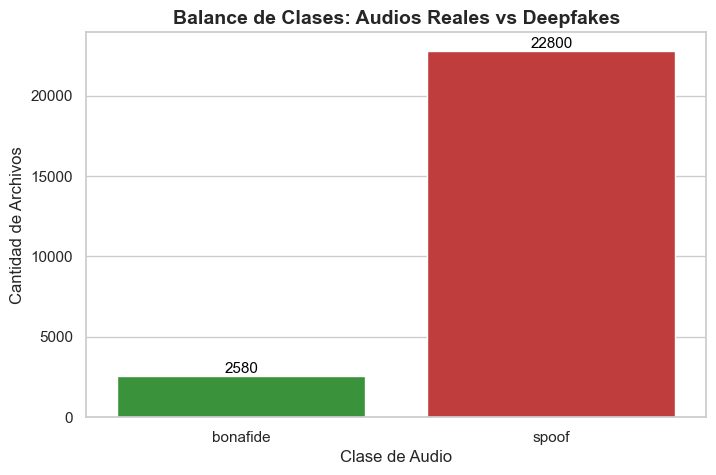

In [7]:
# Crear una figura
plt.figure(figsize=(8, 5))

# Gráfico de barras contando cuántos hay de cada uno
ax = sns.countplot(data=df, x='label', hue='label', palette={'bonafide': '#2ca02c', 'spoof': '#d62728'}, legend=False)

plt.title('Balance de Clases: Audios Reales vs Deepfakes', fontsize=14, fontweight='bold')
plt.xlabel('Clase de Audio', fontsize=12)
plt.ylabel('Cantidad de Archivos', fontsize=12)

# Añadir los números exactos encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

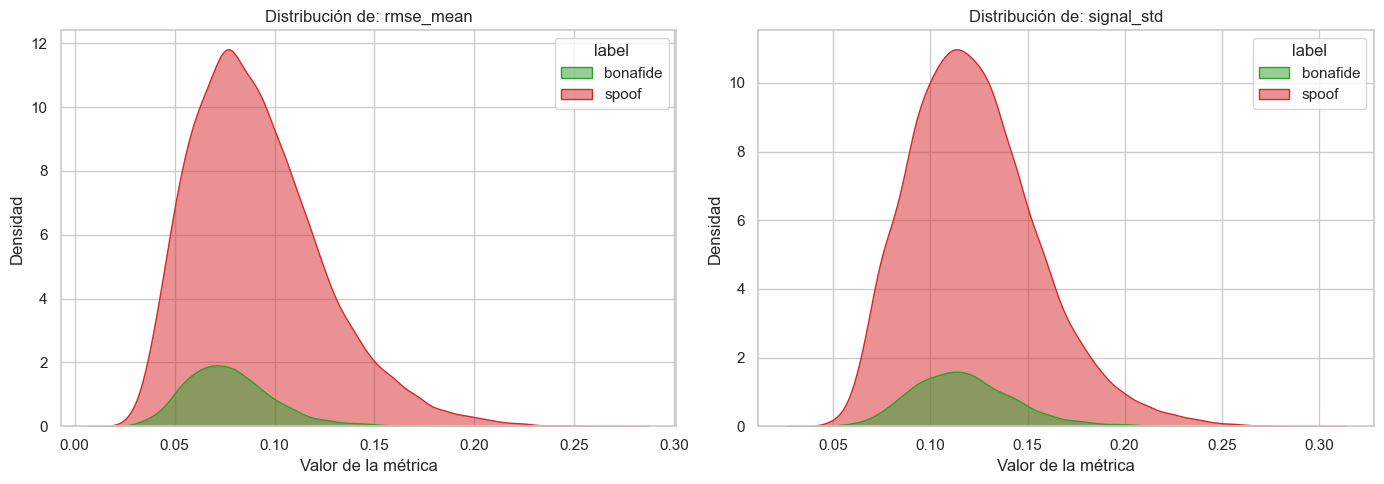

In [13]:
# Selecciona 2 o 3 métricas de tu dataset para analizar
metricas_a_analizar = ['rmse_mean', 'signal_std'] 

plt.figure(figsize=(14, 5))

for i, metrica in enumerate(metricas_a_analizar, 1):
    plt.subplot(1, len(metricas_a_analizar), i)
    
    # KDE Plot: Dibuja las curvas de distribución
    sns.kdeplot(data=df, x=metrica, hue='label', fill=True, 
                palette={'bonafide': '#2ca02c', 'spoof': '#d62728'}, alpha=0.5)
    
    plt.title(f'Distribución de: {metrica}', fontsize=12)
    plt.xlabel('Valor de la métrica')
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

# CONCLUSIÓN ESPERADA: 
# Si las curvas roja y verde están muy separadas, ¡esa métrica es oro! 
# Si están completamente superpuestas, esa métrica no ayudará mucho al modelo.

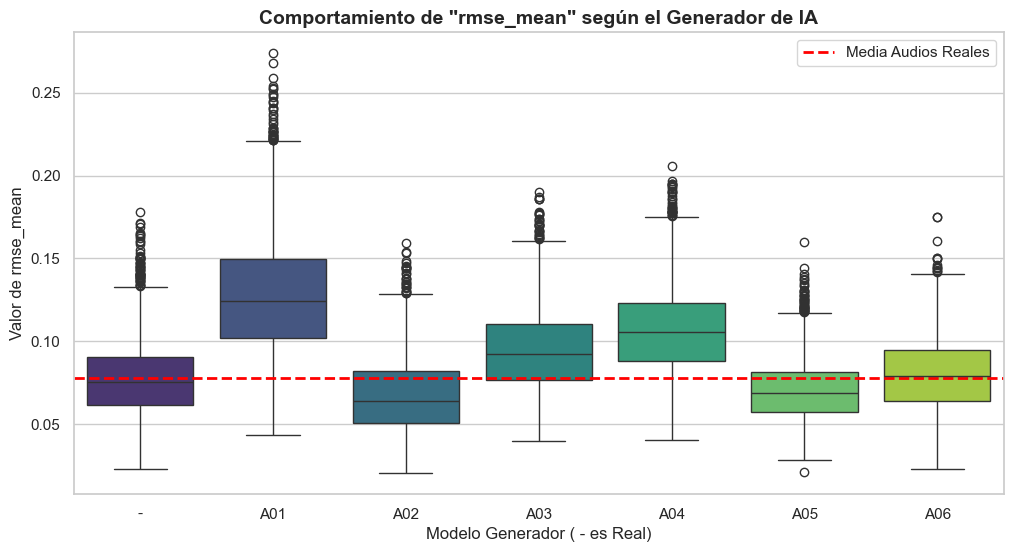

In [14]:
# Pon aquí el nombre de tu mejor métrica numérica
mejor_metrica = 'rmse_mean'

plt.figure(figsize=(12, 6))

# Ordenar los generadores para que el gráfico tenga sentido
orden_generadores = sorted(df['attack_id'].unique())

sns.boxplot(data=df, x='attack_id', y=mejor_metrica, order=orden_generadores, hue='attack_id', palette='viridis', legend=False)

plt.title(f'Comportamiento de "{mejor_metrica}" según el Generador de IA', fontsize=14, fontweight='bold')
plt.xlabel('Modelo Generador ( - es Real)', fontsize=12)
plt.ylabel(f'Valor de {mejor_metrica}', fontsize=12)

# Añadir una línea roja punteada que marque la media de los audios reales para comparar fácilmente
media_real = df[df['attack_id'] == '-'][mejor_metrica].mean()
plt.axhline(media_real, color='red', linestyle='--', linewidth=2, label='Media Audios Reales')
plt.legend()

plt.show()

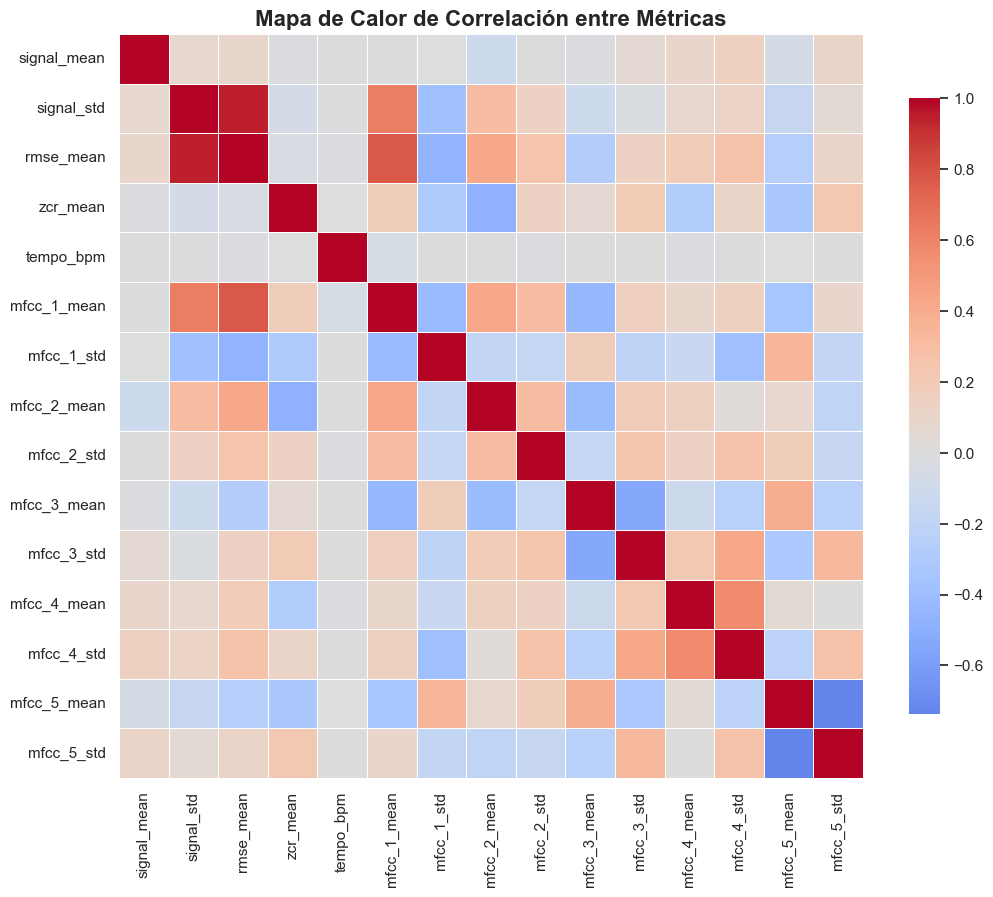

In [12]:
# Seleccionar solo las columnas numéricas (excluimos textos y etiquetas)
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Si tienes 100 características, el gráfico será ilegible. 
# Tomamos solo las primeras 15 para visualizar (puedes ajustar este número)
columnas_a_correlacionar = columnas_numericas[:15]

# Calcular la matriz de correlación
matriz_corr = df[columnas_a_correlacionar].corr()

plt.figure(figsize=(12, 10))

# Crear el mapa de calor
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=16, fontweight='bold')
plt.show()

# CONCLUSIÓN ESPERADA:
# Los cuadrados rojo oscuro (cerca de 1) o azul oscuro (cerca de -1) indican métricas muy correlacionadas. 
# Podrías plantearte eliminar una de las dos en la fase de preprocesamiento.